# Transformers for Video Game Image Super Resolution


**Video Game Super-Resolution** (VGSR)  
Eric Phann, Samantha Michael, Kidus Kidane  
DSBA 6127: AI & Deep Learning


## Introduction

This notebook will explore transformers as a newer, state-of-the-art architecture for video game image super-resolution. The intuition for this is that attention mechanisms will be useful for better detail preservation and prediction as opposed to more traditional methods like convolutional neural networks (CNNs) or generative adversarial networks (GANs).

We will refer to ["Swin IR: Image Restoration Using Swin Transformer"](https://arxiv.org/abs/2108.10257) as baseline research and model for this approach in our project.

## SwinIR

*We leverage SwinIR's GitHub [repository](https://github.com/JingyunLiang/SwinIR) for the below explanations and code.*

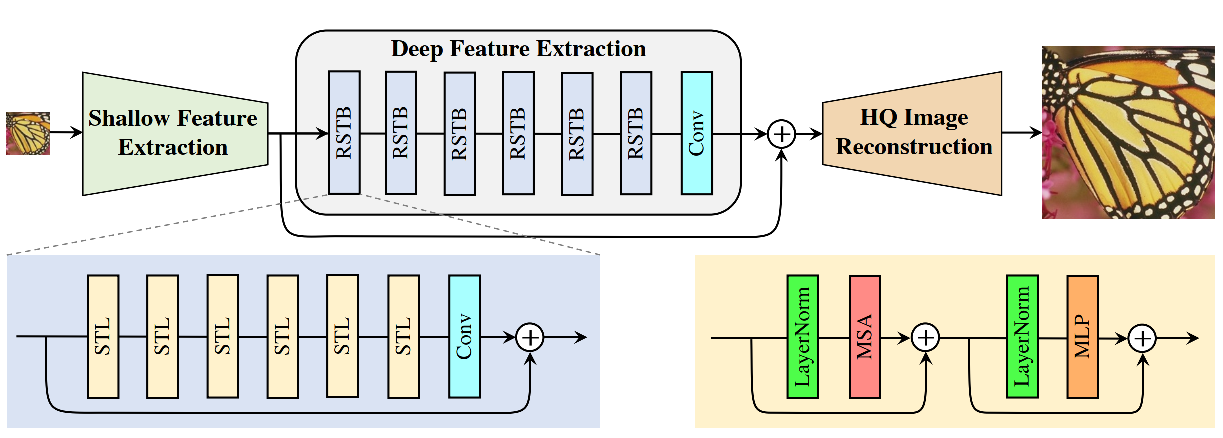

As you can see in the diagram shown, SwinIR is composed of three parts:
- Shallow feature extraction
- Deep feature extraction
- HQ image reconstruction

The deep feature extraction module contains several residual Swin Transformer blocks (RSTB) which consist of several Swin Transformer layers together with a residual connection.  

For reference, a **Swin** Transformer is a hierarchical vision transformer using "**S**hifted **Win**dows". For more info, read the paper [here](https://arxiv.org/abs/2103.14030).


## Import the model

First, install Transformers.

In [60]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Now, load Swin2SR model from Hugging Face. This model upscales 2x.

In [61]:
from transformers import Swin2SRForImageSuperResolution

model = Swin2SRForImageSuperResolution.from_pretrained("caidas/swin2SR-classical-sr-x2-64")

config.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/48.5M [00:00<?, ?B/s]

## Upload Images

Since we have our images loaded to Hugging Face, we can easily import and download a few to try.

Let's see a low resolution video game image.

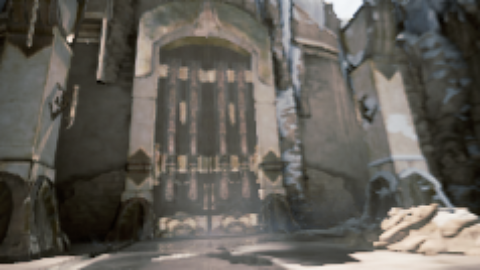

In [64]:
import requests
from PIL import Image

url = "https://huggingface.co/datasets/ericphann/video-game-super-resolution/resolve/main/training-lr/00000.png"

lr = Image.open(requests.get(url, stream=True).raw)
lr

Let's see the high resolution equivalent.

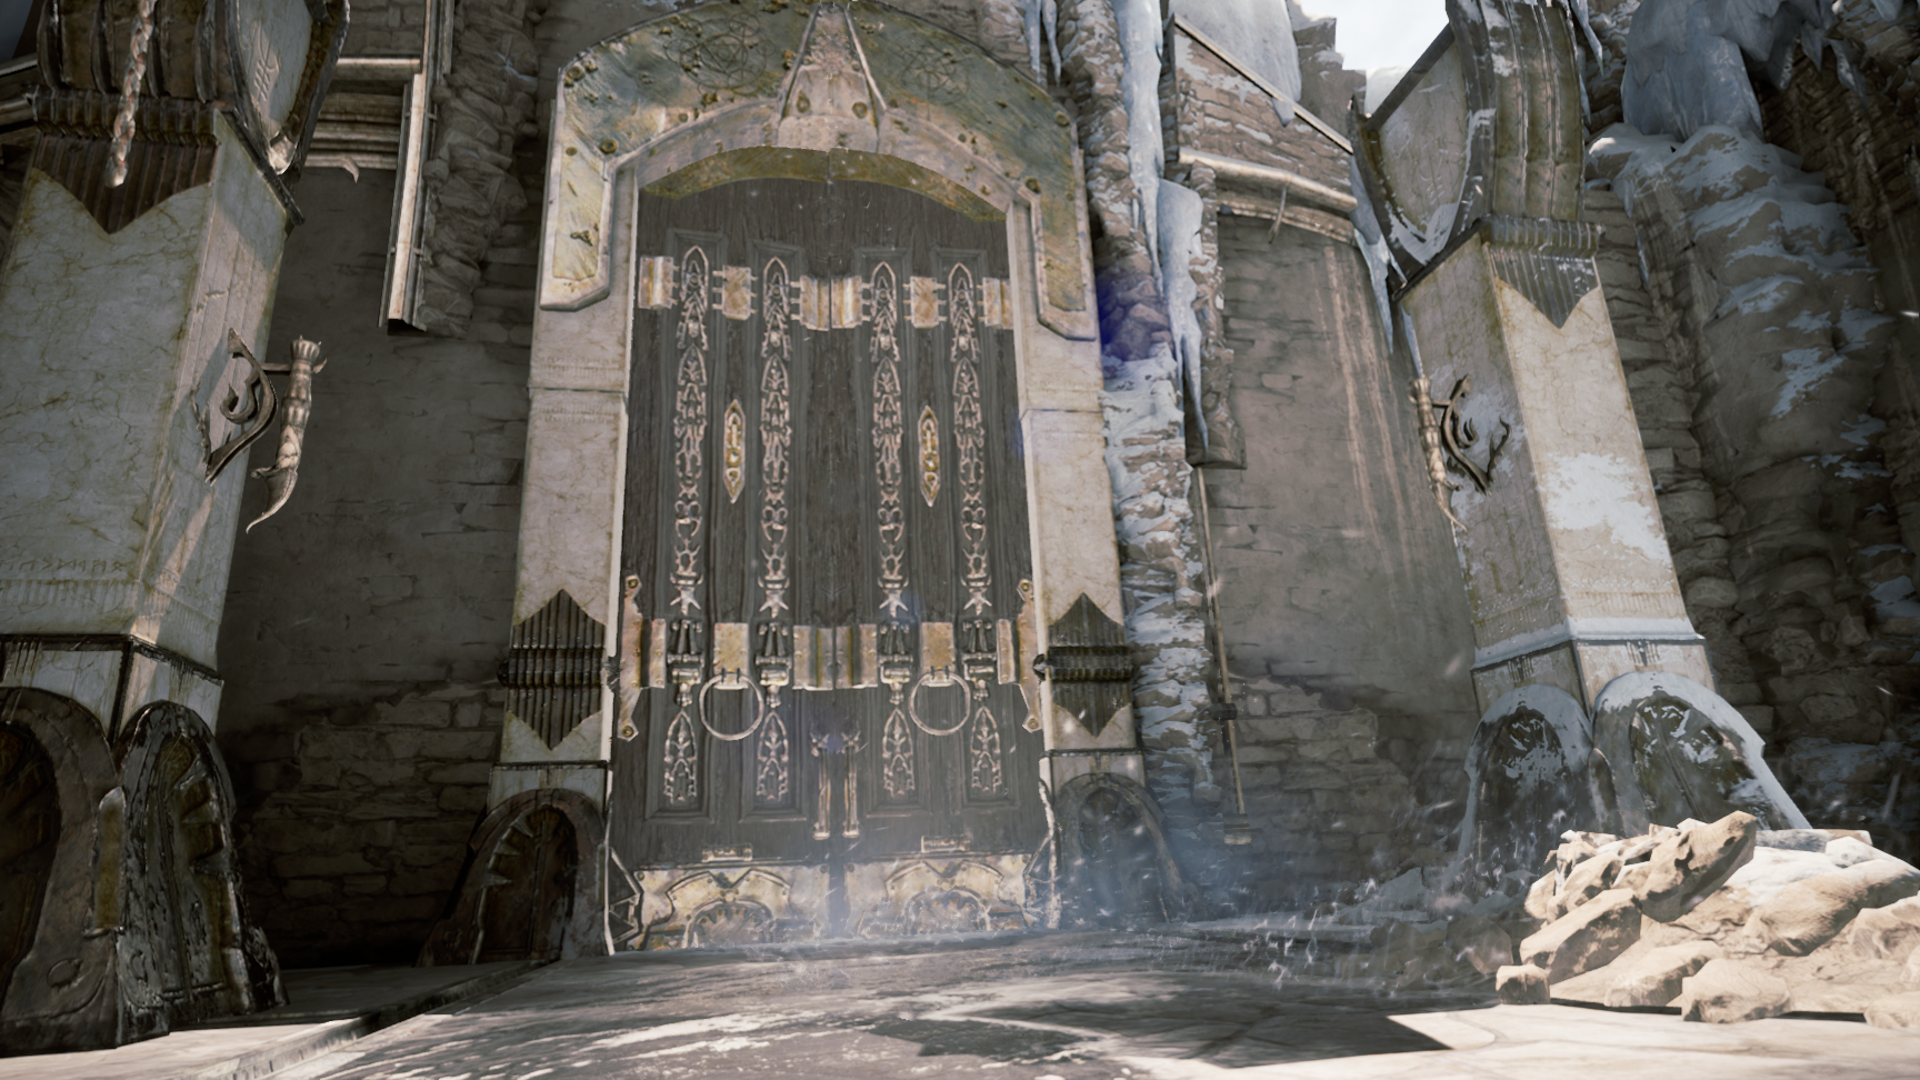

In [65]:
url = "https://huggingface.co/datasets/ericphann/video-game-super-resolution/resolve/main/training-hr/00000.png"

hr = Image.open(requests.get(url, stream=True).raw)
hr

## Prepare image

Swin2SR has a specific image processor, so let's run our low resolution image through that.

In [66]:
from transformers import Swin2SRImageProcessor

processor = Swin2SRImageProcessor()

In [75]:
pixel_values = processor(lr, return_tensors="pt", input_data_format="channels_last").pixel_values
print(pixel_values.shape)

torch.Size([1, 4, 272, 488])


We need to reshape the second column from RGBA (4 channel) to RGB (3 channel).

In [81]:
pixel_values = pixel_values[:,:3, :, :]
print(pixel_values.shape)

torch.Size([1, 3, 272, 488])


## Inference

In [82]:
import torch

with torch.no_grad():
  outputs = model(pixel_values)

## Visualize

The model outputs an upscaled version of our input image.

In [85]:
outputs.reconstruction.shape

torch.Size([1, 3, 544, 976])

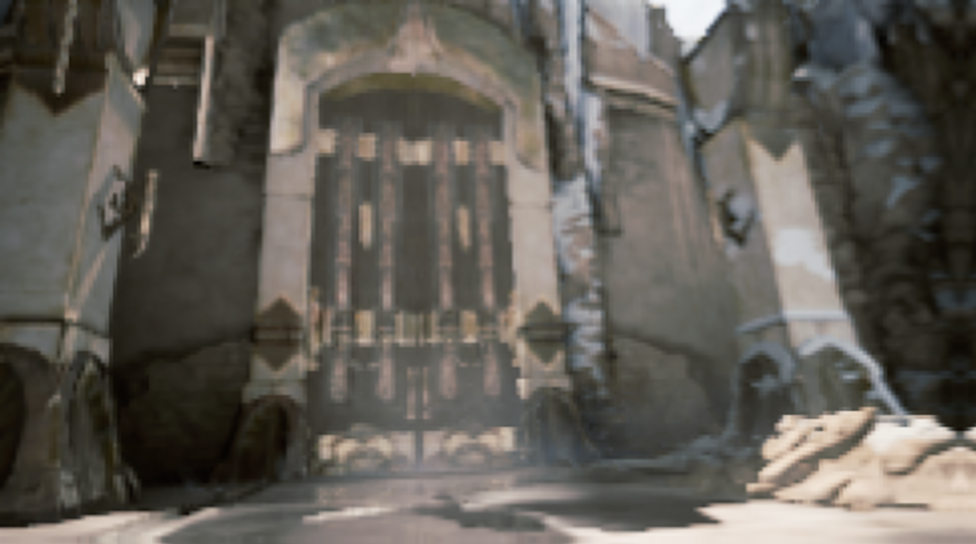

In [86]:
import numpy as np

output = outputs.reconstruction.data.squeeze().float().cpu().clamp_(0, 1).numpy()
output = np.moveaxis(output, source=0, destination=-1)
output = (output * 255.0).round().astype(np.uint8)  # float32 to uint8
Image.fromarray(output)

Just from initial impressions, it is not as good as we'd like. It is still pretty blurry despite a "higher resolution." For the next milestone, we will implement additional metrics and features to help produce better results.